In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

### Method 1

In [18]:

# ============================================================
# 0) STRESS GRADIENT uit LWT-referentie
# ============================================================
Hs_design = 3.65     # [m]  ontwerp-Hs waarvoor F_wave/M_wave gelden
F_wave    = 1.65     # [MN/m] resultante golfkracht bij Hs_design 
x1        = 77     # [m]  afstand tot eerste steunpunt (vakwerkarm)
Wz        = 19.02     # [m^3] weerstandsmoment retaining wall

# Globaal buigend moment bij het steunpunt (overhangend-balkmodel),
M_global_ref = 0.5 * F_wave * x1**2      # [MNm], TOTAAL (niet per m)

# Spanning bij de ontwerpconditie
sigma_ref = M_global_ref / Wz            # [MPa]

# Lineaire spanningsgradiënt per meter Hs
sigma_grad = sigma_ref / Hs_design       # [MPa/m]

print("=== Stap 0: afleiding sigma' ===")
print(f"M_global_ref = {M_global_ref:10.1f} MNm  (bij Hs = {Hs_design} m)")
print(f"sigma_ref    = {sigma_ref:10.2f} MPa   (bij Hs = {Hs_design} m)")
print(f"sigma'       = {sigma_grad:10.2f} MPa/m\n")

# ============================================================
# 1) S-N CURVE (EN 1993-1-9)
# ============================================================
dSigma_C = 71.0                            # FAT-klasse [MPa] (bij 2e6)
dSigma_D = (2 / 5) ** (1 / 3) * dSigma_C   # CAFL       [MPa] (bij 5e6)
dSigma_L = (5 / 100) ** (1 / 5) * dSigma_D # cut-off    [MPa] (bij 1e8)


def allowable_N(dSigma):
    """Toelaatbaar aantal cycli N voor spanningsrange dSigma [MPa]."""
    if dSigma >= dSigma_D:                 # tak m = 3
        return 2e6 * (dSigma_C / dSigma) ** 3
    elif dSigma >= dSigma_L:               # tak m = 5
        return 5e6 * (dSigma_D / dSigma) ** 5
    else:                                  # onder cut-off
        return np.inf


print("=== Stap 1: S-N curve ===")
print(f"dSigma_C = {dSigma_C:6.2f} MPa  (bij 2e6)")
print(f"dSigma_D = {dSigma_D:6.2f} MPa  (bij 5e6, CAFL)")
print(f"dSigma_L = {dSigma_L:6.2f} MPa  (bij 1e8, cut-off)\n")

# ============================================================
# 2) STORMKLASSEN  (methode 1: constante Hs per storm)
# ============================================================
#            klasse         freq [1/jr]   Hs [m]   Tp [s]
storms = [
    ("1/1     jaar",   1.0,      1.33,  8.15),
    ("1/10    jaar",   0.1,      1.72,  8.65),
    ("1/100   jaar",   0.01,     2.19,  10.11),
    ("1/1000  jaar",   0.001,    2.64,  11.01),
    ("1/10000 jaar",   0.0001,   3.13,  10.91),
    ("1/100000 jaar",  0.00001,  3.65,  12.85),
]

# ============================================================
# 3) LEVENSDUUR-PARAMETERS
# ============================================================
design_life  = 100.0            # jaar
T_storm      = 35.0 * 3600.0    # s   (duur van een storm)
n_sluitingen = 330

# ============================================================
# 4) SCHADE PER KLASSE + MINER-SOMMATIE
#    -> per klasse een EIGEN spanningsrange dSigma_i = sigma' * Hs_i
# ============================================================
D_tot = 0.0
print("=== Stap 4: schadeaccumulatie per stormklasse ===")
print(f"{'Klasse':14s} {'Hs':>5s} {'dSigma_i':>9s} "
      f"{'#stormen':>9s} {'n_cycli':>11s} {'N_R':>12s} {'D_i':>9s}")

for name, freq, Hs, Tp in storms:
    dSigma_i    = sigma_grad * Hs            # spanningsrange van deze klasse
    Tm          = Tp / 1.28                  # gemiddelde periode (JONSWAP)
    N_per_storm = T_storm / Tm               # cycli in een 35-uurs storm
    n_storms    = min(freq * n_sluitingen, design_life)
    n_cycli     = N_per_storm * n_storms     # totaal cycli van deze klasse

    N_allow_i = allowable_N(dSigma_i)        # toelaatbaar N bij dSigma_i
    D_i       = n_cycli / N_allow_i          # schadebijdrage van deze klasse
    D_tot    += D_i

    print(f"{name:14s} {Hs:5.2f} {dSigma_i:9.2f} "
          f"{n_storms:9.2f} {n_cycli:11.0f} {N_allow_i:12.0f} {D_i:9.4f}")

# ============================================================
# 5) RESULTAAT
# ============================================================
print(f"\nTotale schade D = {D_tot:.4f}")
if D_tot > 0:
    life = design_life / D_tot
    print(f"Fatigue life    = {life:.1f} jaar")
    print("VOLDOET" if D_tot <= 1.0 else "AFGEKEURD")
else:
    print("Geen vermoeiingsschade (alle spanningen onder cut-off).")


=== Stap 0: afleiding sigma' ===
M_global_ref =     4891.4 MNm  (bij Hs = 3.65 m)
sigma_ref    =     257.17 MPa   (bij Hs = 3.65 m)
sigma'       =      70.46 MPa/m

=== Stap 1: S-N curve ===
dSigma_C =  71.00 MPa  (bij 2e6)
dSigma_D =  52.31 MPa  (bij 5e6, CAFL)
dSigma_L =  28.73 MPa  (bij 1e8, cut-off)

=== Stap 4: schadeaccumulatie per stormklasse ===
Klasse            Hs  dSigma_i  #stormen     n_cycli          N_R       D_i
1/1     jaar    1.33     93.71    100.00     1978896       869869    2.2749
1/10    jaar    1.72    121.19     33.00      615288       402183    1.5299
1/100   jaar    2.19    154.30      3.30       52643       194839    0.2702
1/1000  jaar    2.64    186.01      0.33        4834       111224    0.0435
1/10000 jaar    3.13    220.53      0.03         488        66738    0.0073
1/100000 jaar   3.65    257.17      0.00          41        42085    0.0010

Totale schade D = 4.1267
Fatigue life    = 24.2 jaar
AFGEKEURD


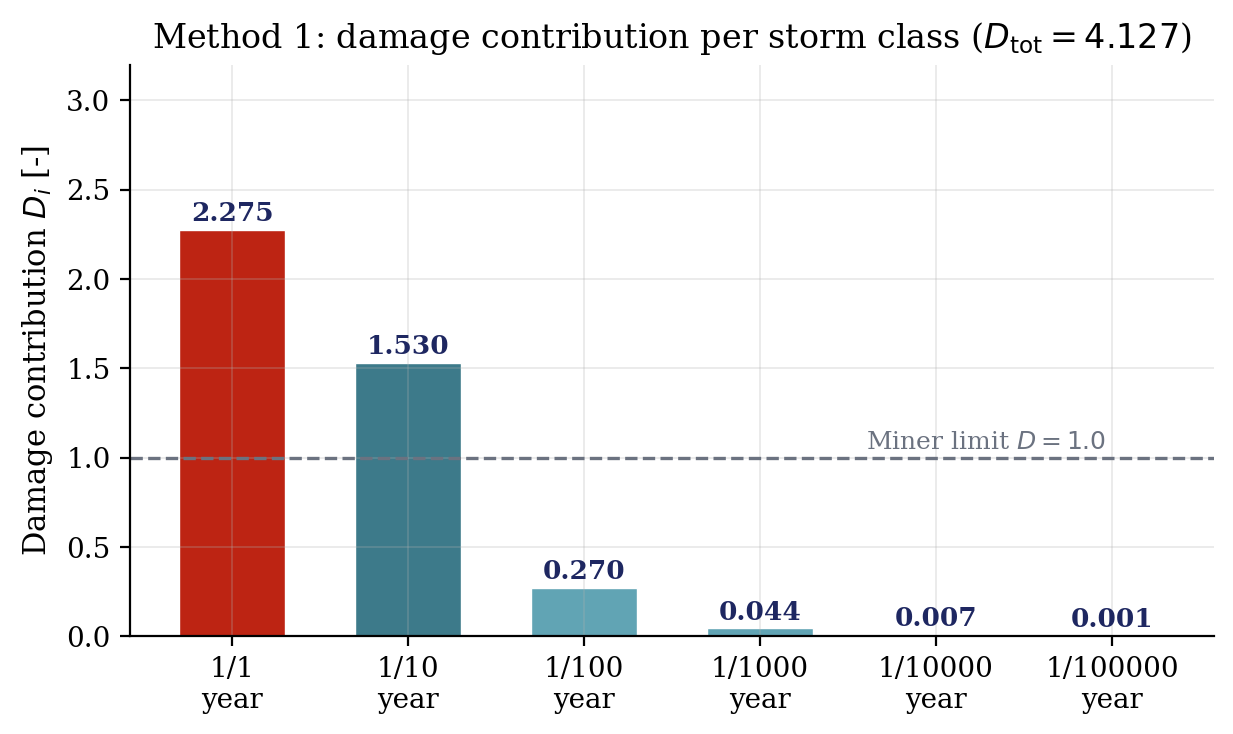

In [19]:
"""
Figure: Method 1 -- fatigue damage contribution per storm class.
"""

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 200,
})

# Colors
NAVY = "#1E2761"
RED = "#BD2413"
TEAL = "#61A4B4"
TEAL_DARK = "#3D7A8A"
GRAY = "#6B7280"

OUT_DIR = "."  


def fig_damage_per_class_m1():
    # Storm classes and their Palmgren-Miner damage contribution D_i,
    labels = ["1/1\nyear", "1/10\nyear", "1/100\nyear", "1/1000\nyear", "1/10000\nyear", "1/100000\nyear"]
    D = [2.275, 1.530, 0.270, 0.044, 0.007, 0.001]

    # Highlight the two dominant, most frequent storm classes
    colors = [RED, TEAL_DARK, TEAL, TEAL, TEAL]

    fig, ax = plt.subplots(figsize=(6.3, 3.8))
    bars = ax.bar(labels, D, color=colors, edgecolor="white", linewidth=0.5, width=0.6)

    # Value labels above each bar
    for b, d in zip(bars, D):
        ax.text(b.get_x() + b.get_width() / 2, d + 0.05, f"{d:.3f}",
                ha="center", fontsize=9.5, color=NAVY, fontweight="bold")

    # Miner damage limit
    ax.axhline(1.0, color=GRAY, ls="--", lw=1.2)
    ax.annotate("Miner limit $D=1.0$", xy=(3.6, 1.05), fontsize=9, color=GRAY)

    ax.set_ylabel("Damage contribution $D_i$ [-]")
    ax.set_title("Method 1: damage contribution per storm class ($D_{\\mathrm{tot}}=4.127$)")
    ax.set_ylim(0, 3.2)

    fig.tight_layout()


plt.show(fig_damage_per_class_m1());